In [44]:
#importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [45]:
df = pd.read_csv('energy.csv')

In [46]:
df.head()

,CustomerID,Age,Gender,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,349df5e3-6023-42aa-aa1c-994ee1150fe1,26,Female,3,183531.73020,2,0,1,39466.46416,0
1,df4892b2-4922-4469-9e30-21327ee5a747,35,Male,1,48129.41355,1,1,0,125134.32740,0
2,26356261-1475-4fe3-a168-3a26588658ad,28,Female,6,69845.04978,1,0,0,139058.54730,0
3,edb9a42d-8418-490f-8a5b-6d19d9b26a10,28,Male,4,69612.56079,2,0,0,119424.51700,0
4,df8ff389-022d-4d08-8c91-b2e17ba7ffc6,30,Male,6,65124.06360,2,1,1,112798.18870,0


In [47]:
# Map the whole column to 1/0
#df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

In [48]:
from sklearn.preprocessing import OneHotEncoder

gender_encoder = OneHotEncoder(sparse_output=False)

# Encode a categorical column
encoded = gender_encoder.fit_transform(df[['Gender']])

# Convert to DataFrame and join back
encoded_df = pd.DataFrame(encoded, columns=gender_encoder.get_feature_names_out(['Gender']))
df = pd.concat([df, encoded_df], axis=1)

# Drop the original column
df.drop('Gender', axis=1)

,CustomerID,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_Female,Gender_Male
0,349df5e3-6023-42aa-aa1c-994ee1150fe1,26,3,183531.73020,2,0,1,39466.46416,0,1.0,0.0
1,df4892b2-4922-4469-9e30-21327ee5a747,35,1,48129.41355,1,1,0,125134.32740,0,0.0,1.0
2,26356261-1475-4fe3-a168-3a26588658ad,28,6,69845.04978,1,0,0,139058.54730,0,1.0,0.0
3,edb9a42d-8418-490f-8a5b-6d19d9b26a10,28,4,69612.56079,2,0,0,119424.51700,0,0.0,1.0
4,df8ff389-022d-4d08-8c91-b2e17ba7ffc6,30,6,65124.06360,2,1,1,112798.18870,0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
995,b17c184f-abdd-4e3d-b006-0446ff0ae373,59,1,32547.43637,2,1,1,71309.24809,0,0.0,1.0
996,073cc549-b8cf-469b-9dda-e763c607ed48,26,6,110655.63920,1,1,0,88295.27443,0,1.0,0.0
997,eb0425fa-8e61-4ab9-848b-595207b73932,19,7,205655.68550,2,1,0,26550.09952,0,1.0,0.0
998,582330bb-dee7-448d-a3c1-0c37ddaa7ab6,69,2,239952.53990,2,1,1,120258.72060,0,0.0,1.0


In [49]:
df.head()

,CustomerID,Age,Gender,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_Female,Gender_Male
0,349df5e3-6023-42aa-aa1c-994ee1150fe1,26,Female,3,183531.73020,2,0,1,39466.46416,0,1.0,0.0
1,df4892b2-4922-4469-9e30-21327ee5a747,35,Male,1,48129.41355,1,1,0,125134.32740,0,0.0,1.0
2,26356261-1475-4fe3-a168-3a26588658ad,28,Female,6,69845.04978,1,0,0,139058.54730,0,1.0,0.0
3,edb9a42d-8418-490f-8a5b-6d19d9b26a10,28,Male,4,69612.56079,2,0,0,119424.51700,0,0.0,1.0
4,df8ff389-022d-4d08-8c91-b2e17ba7ffc6,30,Male,6,65124.06360,2,1,1,112798.18870,0,0.0,1.0


In [50]:
df.drop('CustomerID', axis=1, )

,Age,Gender,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_Female,Gender_Male
0,26,Female,3,183531.73020,2,0,1,39466.46416,0,1.0,0.0
1,35,Male,1,48129.41355,1,1,0,125134.32740,0,0.0,1.0
2,28,Female,6,69845.04978,1,0,0,139058.54730,0,1.0,0.0
3,28,Male,4,69612.56079,2,0,0,119424.51700,0,0.0,1.0
4,30,Male,6,65124.06360,2,1,1,112798.18870,0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
995,59,Male,1,32547.43637,2,1,1,71309.24809,0,0.0,1.0
996,26,Female,6,110655.63920,1,1,0,88295.27443,0,1.0,0.0
997,19,Female,7,205655.68550,2,1,0,26550.09952,0,1.0,0.0
998,69,Male,2,239952.53990,2,1,1,120258.72060,0,0.0,1.0


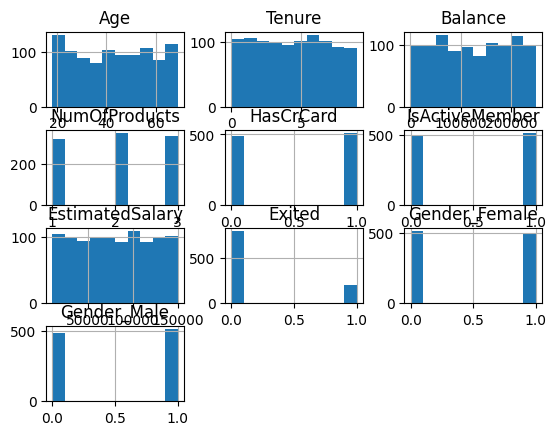

In [51]:
df.hist()
plt.show()

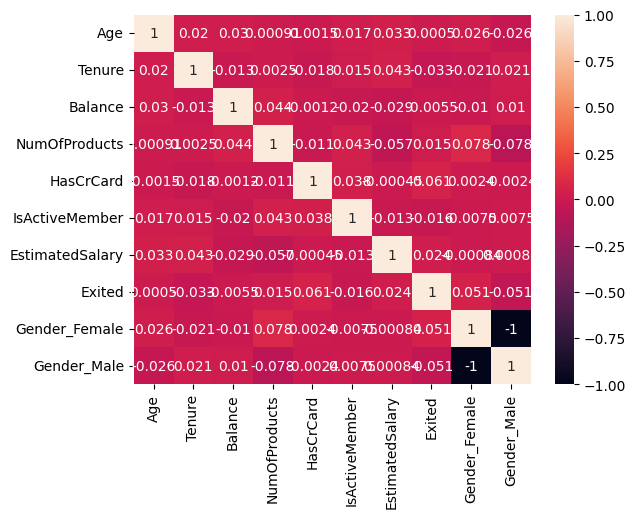

In [52]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [53]:
x =  df.drop(['CustomerID', 'Gender', 'Exited'], axis=1).values
y = df.iloc[:, 9].values

In [54]:
print(x)

[[2.60000000e+01 3.00000000e+00 1.83531730e+05 ... 3.94664642e+04
  1.00000000e+00 0.00000000e+00]
 [3.50000000e+01 1.00000000e+00 4.81294135e+04 ... 1.25134327e+05
  0.00000000e+00 1.00000000e+00]
 [2.80000000e+01 6.00000000e+00 6.98450498e+04 ... 1.39058547e+05
  1.00000000e+00 0.00000000e+00]
 ...
 [1.90000000e+01 7.00000000e+00 2.05655685e+05 ... 2.65500995e+04
  1.00000000e+00 0.00000000e+00]
 [6.90000000e+01 2.00000000e+00 2.39952540e+05 ... 1.20258721e+05
  0.00000000e+00 1.00000000e+00]
 [4.50000000e+01 4.00000000e+00 1.46513131e+05 ... 1.12661996e+05
  1.00000000e+00 0.00000000e+00]]


In [55]:
print(y)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1
 1 1 1 0 1 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 1 0 0 1 1 0 0 0 1 1 0 0 0 1 1 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 1 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1
 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 1 0 0 0 0 1
 0 0 1 0 0 0 0 1 1 1 0 0 1 1 0 0 0 0 0 0 1 0 0 1 1 0 0 1 0 0 0 0 0 0 1 0 0
 1 0 0 0 0 1 1 0 0 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 1 0 1 0 1
 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 1 0 0 1 1 0 1 1 1 0 0 0 1 0 0 0 0 0
 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0
 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 1 0 0 1 0 0 0 0 1
 0 0 1 0 0 1 0 1 0 0 1 0 

In [56]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, stratify = y, random_state = 24)

In [57]:

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)


In [58]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 24)
classifier.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",24
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [59]:
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = classifier.predict(x_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[159   0]
 [ 41   0]]


0.795

<Axes: >

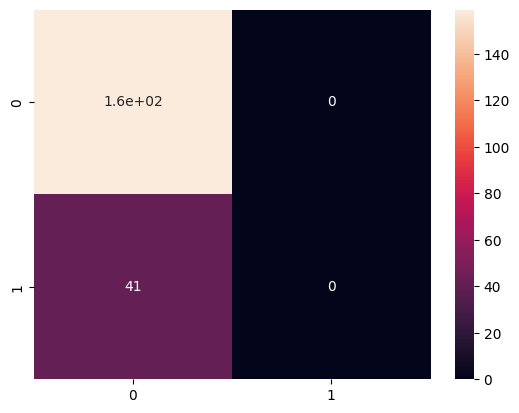

In [60]:
sns.heatmap(cm, annot=True)

In [61]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89       159
           1       0.00      0.00      0.00        41

    accuracy                           0.80       200
   macro avg       0.40      0.50      0.44       200
weighted avg       0.63      0.80      0.70       200



c:\Users\USER\Control\day1\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\Control\day1\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\Control\day1\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
